<a href="https://colab.research.google.com/github/sjhallo07/Quantum_Relativistic_Engine/blob/main/bridge_integrated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌉 Integrated Semantic + Lorenz EKF Bridge

Este script utiliza un puente de búsqueda semántica para recuperar parámetros de ajuste de un corpus textual y, a continuación, ejecuta la estimación del Filtro de Kalman Extendido (EKF) de Lorenz con esos parámetros.

Demuestra cómo las consultas en lenguaje natural pueden utilizarse para adaptar la configuración de los filtros sobre la marcha (Aprendizaje Procedural).

**Componentes:**
- `SemanticBridge`: recupera pasajes relevantes y extrae parámetros numéricos.
- `Lorenz EKF bridge`: ejecuta la estimación de estado, el monitoreo de Lyapunov y la recuperación segura.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import torch
import re
from sentence_transformers import SentenceTransformer, util

In [2]:
# ------------------------------------------------------------
# 1. Semantic Bridge (retrieves and extracts parameters)
# ------------------------------------------------------------
class SemanticBridge:
    """
    Reusable semantic search bridge that retrieves relevant passages
    and extracts numerical parameters (e.g., lambda_thr, beta_meta).
    """
    def __init__(self, model_name: str = "intfloat/multilingual-e5-large", corpus: list = None):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = SentenceTransformer(model_name, device=self.device)

        if corpus is None:
            self.corpus = [
                "Pages 1-2: Context of the Annus Mirabilis (1905)...",
                "Pages 2-3: Inconsistencies of 19th-Century Classical Physics...",
                "Pages 3-4: Consequences of Special Relativity...",
                "Pages 4-5: Photoelectric Effect and Wave-Particle Duality...",
                "Pages 5-6: Foundations of Quantum Mechanics and Probability...",
                "Pages 6-7: Quantum Electrodynamics (QED) and Extreme Precision...",
                "Pages 8-10: General Relativity and Geometrization of Gravity...",
                "Pages 10-12: Rejection of Quantum Mechanics and Unified Field Theory..."
            ]
        else:
            self.corpus = corpus

        self.passages = [f"passage: {chunk}" for chunk in self.corpus]
        self.corpus_embeddings = self.model.encode(
            self.passages, convert_to_tensor=True, device=self.device
        )
        print(f"✅ SemanticBridge initialized with {len(self.corpus)} passages on {self.device}.")

    def query(self, natural_language_query: str, top_k: int = 1):
        query_text = f"query: {natural_language_query}"
        query_embedding = self.model.encode(query_text, convert_to_tensor=True, device=self.device)
        hits = util.semantic_search(query_embedding, self.corpus_embeddings, top_k=top_k)[0]
        retrieved = [self.corpus[hit['corpus_id']] for hit in hits]
        scores = [hit['score'] for hit in hits]
        return retrieved, scores

    def extract_parameters(self, text: str):
        params = {}
        eq_match = re.search(r'([A-Za-zαβγδϵμ][\s]*[=≈][\s]*[^.\n]+)', text)
        if eq_match: params['equation'] = eq_match.group(1).strip()

        num_match = re.search(r'(\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)', text)
        if num_match:
            try: params['numeric_value'] = float(num_match.group(1))
            except ValueError: pass

        symbol_match = re.search(r'\b(α|β|γ|δ|ϵ|μ|π|h_bar|ħ|c|G|e)\b', text)
        if symbol_match: params['symbol'] = symbol_match.group(1)

        match = re.search(r'threshold\s*(?:to|=|:)?\s*([\d.]+)', text, re.I)
        if match: params['lambda_thr'] = float(match.group(1))

        match = re.search(r'beta_meta\s*(?:=|:\s*)?([\d.]+)', text, re.I)
        if match: params['beta_meta'] = float(match.group(1))

        match = re.search(r'blend[_ ]?factor\s*(?:=|:\s*)?([\d.]+)', text, re.I)
        if match: params['blend_factor'] = float(match.group(1))

        match = re.search(r'\bR\s*(?:=|:\s*)?([\d.]+)', text, re.I)
        if match: params['R'] = float(match.group(1))

        match = re.search(r'Q_base.*?diag\(\[([\d.]+),', text, re.I)
        if match:
            val = float(match.group(1))
            params['Q_base'] = [val, val, val]

        return params

    def get_advice(self, query: str):
        retrieved, scores = self.query(query, top_k=1)
        if not retrieved: return None
        text = retrieved[0]
        params = self.extract_parameters(text)
        return {'text': text, 'similarity_score': scores[0], 'parameters': params}

In [3]:
# ------------------------------------------------------------
# 2. Lorenz EKF Bridge (state estimation, Lyapunov, safe memory)
# ------------------------------------------------------------
def lorenz_deriv(state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x*(rho - z) - y
    dz = x*y - beta*z
    return np.array([dx, dy, dz])

def lorenz_step(state, dt):
    t = np.array([0, dt])
    sol = odeint(lorenz_deriv, state, t)
    return sol[1]

def lorenz_jacobian(state):
    x, y, z = state
    sigma, rho, beta = 10.0, 28.0, 8.0/3.0
    J = np.array([
        [-sigma, sigma, 0],
        [rho - z, -1, -x],
        [y, x, -beta]
    ])
    return J

def ekf_predict(x, P, dt, Q):
    x_pred = lorenz_step(x, dt)
    F = np.eye(3) + lorenz_jacobian(x) * dt
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred

def ekf_update(x_pred, P_pred, z, H, R):
    y = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_upd = x_pred + K @ y
    P_upd = (np.eye(3) - K @ H) @ P_pred
    return x_upd, P_upd, y, K

def update_lyapunov(delta, F, dt, lambda_avg, alpha=0.95):
    delta_new = F @ delta
    norm_old = np.linalg.norm(delta)
    norm_new = np.linalg.norm(delta_new)
    if norm_old < 1e-12:
        lambda_inst = 0.0
    else:
        lambda_inst = (1.0/dt) * np.log(norm_new / norm_old)
    lambda_avg = alpha * lambda_avg + (1 - alpha) * lambda_inst
    if norm_new > 1e-12:
        delta_new = delta_new / norm_new
    return delta_new, lambda_avg, lambda_inst

def adapt_Q(Q_base, lambda_avg, lambda_thr=1.2, beta=0.5):
    if lambda_avg > lambda_thr:
        factor = np.exp(beta * (lambda_avg - lambda_thr))
        factor = min(factor, 10.0)
        return Q_base * factor
    return Q_base

class SafeMemory:
    def __init__(self, safe_state, max_size=30, max_age_steps=100):
        self.safe_state = safe_state.copy()
        self.buffer = []
        self.max_size = max_size
        self.max_age = max_age_steps

    def add(self, state, innov, step):
        if innov < 0.5:
            self.buffer.append((state.copy(), innov, step))
            self.buffer = [(s, i, st) for (s, i, st) in self.buffer if step - st < self.max_age]
            if len(self.buffer) > self.max_size:
                self.buffer.pop(0)

    def recover(self, current_state, current_innov, chaos_detected, innov_high_thr=2.0, blend_factor=0.2):
        if chaos_detected and current_innov > innov_high_thr:
            if self.buffer:
                best_state, best_innov, _ = max(self.buffer, key=lambda x: x[2])
                print(f"🔄 Bridge recovery: blended with recent good state (innov={best_innov:.3f})")
            else:
                best_state = self.safe_state
                print("🔄 Bridge recovery: blended with safe state (no recent good)")
            new_state = (1 - blend_factor) * current_state + blend_factor * best_state
            return new_state
        return current_state

def run_lorenz_bridge(dt=0.01, T=20.0, x0_true=np.array([1.0,1.0,1.0]), x_safe=np.array([2.0,2.0,2.0]),
                      Q_base=np.diag([0.5,0.5,0.5]), R=np.array([[0.1]]),
                      lambda_thr=1.2, beta_meta=0.5, alpha_lambda=0.95,
                      innov_high_thr=2.0, blend_factor=0.2):
    n_steps = int(T / dt)
    H = np.array([[1.0, 0.0, 0.0]])
    x_est = x_safe.copy()
    P = np.eye(3) * 5.0
    lambda_avg = 0.0
    delta_pert = np.random.randn(3) * 1e-6
    memory = SafeMemory(safe_state=x_safe, max_size=30, max_age_steps=100)

    true_traj, est_traj, innovs, lyaps, q_factors = [], [], [], [], []
    true_state = x0_true
    measurements = []

    for _ in range(n_steps):
        true_state = lorenz_step(true_state, dt)
        true_traj.append(true_state)
        z = true_state[0] + np.random.randn() * np.sqrt(R[0,0])
        measurements.append(z)

    state = x_est.copy()
    P_state = P
    for i, z in enumerate(measurements):
        F_jac = np.eye(3) + lorenz_jacobian(state) * dt
        delta_pert, lambda_avg, _ = update_lyapunov(delta_pert, F_jac, dt, lambda_avg, alpha_lambda)
        lyaps.append(lambda_avg)

        Q_adapt = adapt_Q(Q_base, lambda_avg, lambda_thr, beta_meta)
        q_factors.append(np.linalg.norm(Q_adapt) / np.linalg.norm(Q_base))

        state_pred, P_pred = ekf_predict(state, P_state, dt, Q_adapt)
        state_upd, P_upd, y, _ = ekf_update(state_pred, P_pred, z, H, R)
        innov = np.linalg.norm(y)
        innovs.append(innov)

        memory.add(state_upd, innov, i)
        chaos_flag = (lambda_avg > lambda_thr)
        state_upd = memory.recover(state_upd, innov, chaos_flag, innov_high_thr, blend_factor)
        if chaos_flag: P_upd = P_upd * 1.1

        state = state_upd
        P_state = P_upd
        est_traj.append(state)

    return (np.array(true_traj), np.array(est_traj), np.array(lyaps), np.array(innovs), np.array(q_factors))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

✅ SemanticBridge initialized with 5 passages on cpu.
🔍 Retrieved advice:
 When chaos is detected and innovation exceeds 2.0, use a blend factor of 0.2 to softly pull the state toward a safe point.

📊 Extracted parameters: {'numeric_value': 2.0}

🚀 Running Lorenz EKF bridge with:
   lambda_thr = 1.2
   beta_meta = 0.5
   blend_factor = 0.2
   R = 0.1
   Q_base = diag([0.5, 0.5, 0.5])


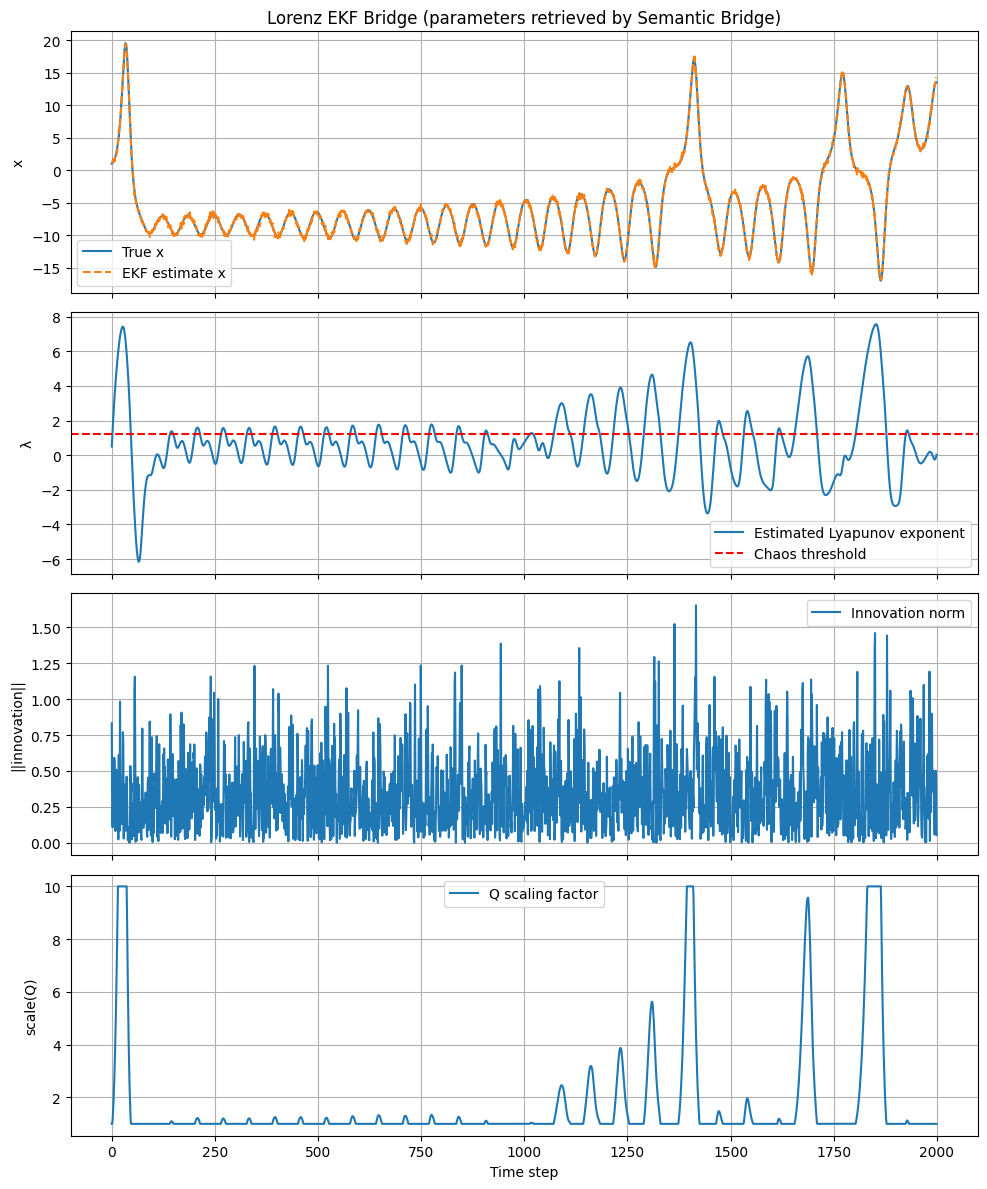

In [4]:
# ------------------------------------------------------------
# 3. Main: Use Semantic Bridge to retrieve parameters
# ------------------------------------------------------------
tuning_corpus = [
    "For the Lorenz system, the maximum Lyapunov exponent is about 0.9. Set Lyapunov threshold to 1.2 to avoid false chaos triggers.",
    "If chaos persists and innovation remains above 3.0, increase beta_meta to 0.8 to speed up the increase of Q.",
    "When chaos is detected and innovation exceeds 2.0, use a blend factor of 0.2 to softly pull the state toward a safe point.",
    "Measurement noise R should be 0.1 for clean x measurements. If tracking is poor, reduce R to 0.05 to trust measurements more.",
    "The base process noise covariance Q_base should be diag([0.5, 0.5, 0.5]) for normal operation. In extreme chaos, increase Q_base to diag([1.0, 1.0, 1.0])."
]

semantic_bridge = SemanticBridge(corpus=tuning_corpus)
query = "Chaos detected, what parameters should I adjust?"
advice = semantic_bridge.get_advice(query)

if advice:
    print("🔍 Retrieved advice:\n", advice['text'])
    print("\n📊 Extracted parameters:", advice['parameters'])
    params = advice['parameters']
else:
    print("⚠️ No advice retrieved. Using default parameters.")
    params = {}

lambda_thr = params.get('lambda_thr', 1.2)
beta_meta = params.get('beta_meta', 0.5)
blend_factor = params.get('blend_factor', 0.2)
R_val = params.get('R', 0.1)
R = np.array([[R_val]])
Q_base_vals = params.get('Q_base', [0.5, 0.5, 0.5])
Q_base = np.diag(Q_base_vals)

print(f"\n🚀 Running Lorenz EKF bridge with:\n"
      f"   lambda_thr = {lambda_thr}\n"
      f"   beta_meta = {beta_meta}\n"
      f"   blend_factor = {blend_factor}\n"
      f"   R = {R_val}\n"
      f"   Q_base = diag({Q_base_vals})")

true_traj, est_traj, lyaps, innovs, q_factors = run_lorenz_bridge(
    lambda_thr=lambda_thr, beta_meta=beta_meta, blend_factor=blend_factor, R=R, Q_base=Q_base
)

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
axes[0].plot(true_traj[:, 0], label='True x')
axes[0].plot(est_traj[:, 0], '--', label='EKF estimate x')
axes[0].set_ylabel('x')
axes[0].legend()
axes[0].grid(True)
axes[0].set_title('Lorenz EKF Bridge (parameters retrieved by Semantic Bridge)')

axes[1].plot(lyaps, label='Estimated Lyapunov exponent')
axes[1].axhline(lambda_thr, color='r', linestyle='--', label='Chaos threshold')
axes[1].set_ylabel('λ')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(innovs, label='Innovation norm')
axes[2].set_ylabel('||innovation||')
axes[2].legend()
axes[2].grid(True)

axes[3].plot(q_factors, label='Q scaling factor')
axes[3].set_ylabel('scale(Q)')
axes[3].set_xlabel('Time step')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()